# IMPORTAMOS LIBRERÍAS

In [1]:
import pandas as pd
import numpy as np 
import os
import pytz
import pandas_market_calendars as mcal
from datetime import time
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import gmean

# LEEMOS LOS DATOS

Hacemos un bucle para meter todos los dataframes (26) en una lista y los vamos modificando.

In [2]:
carpeta = "Datos/Originales/DowJones"

# Lista de los archivos CSV en la carpeta
archivos = [f for f in os.listdir(carpeta) if f.endswith('.csv')]

lista_dfs = []

for i, archivo in enumerate(archivos):
    ruta_completa = os.path.join(carpeta, archivo)
    lista_dfs.append(pd.read_csv(ruta_completa))

### DEFINIMOS FUNCIÓN PARA DETERMINAR SI EL REGISTRO DE CADA INSTANCIA ESTÁ EN EL HORARIO DE APERTURA DEL MERCADO EN NUEVA YORK (9:30-16:30).
Pasamos la fecha dada a horario de Nueva York, y si la hora es antes de las 9:30, el registro se pasa al día anterior, y si está después de las 16:30, se pasa al día siguiente.

In [3]:
def assign_trading_day(ts, MARKET_CLOSE, MARKET_OPEN):
    local_time = ts.tz_convert('America/New_York').time()
    date = ts.tz_convert('America/New_York').date()

    if local_time < MARKET_OPEN:
        # Antes de la apertura → se asigna al día anterior
        new_date = pd.Timestamp(date) - pd.Timedelta(days=1)
    elif local_time > MARKET_CLOSE:
        # Después del cierre → se asigna al día siguiente
        new_date = pd.Timestamp(date) + pd.Timedelta(days=1)
    else:
        new_date = pd.Timestamp(date)

    return new_date

Ahora (tarda ~1min): 
1. Guardamos los días que está abierto ese mercado (el NYSE).
2. Ordenamos los dfs por la fecha.
3. La variable date la convertimos a tipo fecha (estaba como string).
4. Creamos la variable trading_day aplicando la función anterior, es decir, pasamos al horario de Nueva York y arreglamos los registros fuera de horario.
5. Por último, filtramos los dfs (variable trading_day) por los días que está abierto el NYSE.

In [4]:
# Calendario oficial NYSE
nyse = mcal.get_calendar("NYSE")
valid_days = nyse.valid_days(start_date="2018-01-01", end_date="2021-12-31").tz_convert('America/New_York').normalize()

# Rango horario del NYSE
MARKET_OPEN = time(9, 30)
MARKET_CLOSE = time(16, 30)

for df in lista_dfs:
    df.sort_values('date',inplace=True)

    # Convertir la columna 'date' a datetime con zona UTC
    df["date"] = pd.to_datetime(df["date"], utc=True)

    # Reasignar registros fuera del rango horario
    df["trading_day"] = df["date"].apply(assign_trading_day, MARKET_CLOSE=MARKET_CLOSE, MARKET_OPEN=MARKET_OPEN).dt.normalize()

    df["trading_day"] = df["trading_day"].dt.date
    valid_set = set(valid_days.date)

    # Filtrar solo días hábiles
    df = df[df["trading_day"].isin(valid_set)].copy()
    
    lista_dfs[i] = df

In [5]:
lista_dfs[0].head()

,open,high,low,last,close,volume,date,symbol,exchange,trading_day
722,193.63,193.920,192.96,NaN,193.000,NaN,2018-06-06 17:30:00+00:00,AAPL,IEXG,2018-06-06
721,192.98,193.040,191.95,NaN,192.405,NaN,2018-06-06 18:00:00+00:00,AAPL,IEXG,2018-06-06
720,192.72,192.765,191.95,NaN,192.405,NaN,2018-06-06 18:30:00+00:00,AAPL,IEXG,2018-06-06
719,192.44,193.260,192.43,NaN,193.070,NaN,2018-06-06 19:00:00+00:00,AAPL,IEXG,2018-06-06
718,193.17,193.260,192.77,NaN,193.070,NaN,2018-06-06 19:30:00+00:00,AAPL,IEXG,2018-06-06


## PARA ANALIZAR LAS SERIES TEMPORALES ENTRE SÍ, TIENEN QUE TENER EL MISMO RANGO, ASÍ QUE MIRAMOS LA FECHA MÍNIMA Y MÁXIMA DE CADA SERIE 

In [6]:
##MIRAMOS LA FECHA MÁS PEQUEÑA Y MÁS GRANDE DE CADA DF PARA PONERLOS TODOS EN EL MISMO RANGO
fechas = {'minima':[], 'maxima':[]}
for i,df in enumerate(lista_dfs):
    fecha_min = df['trading_day'].min()
    fecha_max = df['trading_day'].max()

    fechas['minima'].append(fecha_min)
    fechas['maxima'].append(fecha_max)


    print(f'Fecha min del df{i}: {fecha_min} y max: {fecha_max}')

print(f"La fecha más reciente para empezar las series: {pd.Series(fechas['minima']).max()} | La última fecha para acabar las series: {pd.Series(fechas['maxima']).min()}")

Fecha min del df0: 2018-06-06 y max: 2021-07-01
Fecha min del df1: 2020-05-29 y max: 2021-07-01
Fecha min del df2: 2020-05-29 y max: 2021-07-01
Fecha min del df3: 2020-05-29 y max: 2021-07-01
Fecha min del df4: 2018-06-11 y max: 2021-07-01
Fecha min del df5: 2020-05-29 y max: 2021-07-01
Fecha min del df6: 2020-05-29 y max: 2021-07-01
Fecha min del df7: 2020-05-29 y max: 2021-07-01
Fecha min del df8: 2020-05-29 y max: 2021-07-01
Fecha min del df9: 2020-05-29 y max: 2021-07-01
Fecha min del df10: 2018-06-11 y max: 2021-07-01
Fecha min del df11: 2020-05-29 y max: 2021-07-01
Fecha min del df12: 2020-05-29 y max: 2021-07-01
Fecha min del df13: 2018-06-07 y max: 2021-07-01
Fecha min del df14: 2020-05-29 y max: 2021-07-01
Fecha min del df15: 2020-05-29 y max: 2021-07-01
Fecha min del df16: 2020-05-29 y max: 2021-07-01
Fecha min del df17: 2020-05-29 y max: 2021-07-01
Fecha min del df18: 2020-05-29 y max: 2021-07-01
Fecha min del df19: 2020-05-29 y max: 2021-07-01
Fecha min del df20: 2020-05-29

LA SERIE QUE MAS TARDE EMPIEZA ES EN 2020-06-02, ASI QUE FILTRAMOS TODAS POR ESA FECHA PARA ADELANTE.\
TODAS ACABAN EN 2021-07-01.

In [7]:
fecha_inicio = pd.Timestamp("2020-06-02", tz="America/New_York").date()

for i, df in enumerate(lista_dfs):
    df = df[df['trading_day'] >= fecha_inicio]
    lista_dfs[i] = df

In [8]:
lista_dfs[0].head()

,open,high,low,last,close,volume,date,symbol,exchange,trading_day
20915,320.870,320.905,320.815,NaN,320.875,NaN,2020-06-01 20:35:00+00:00,AAPL,IEXG,2020-06-02
20914,320.935,321.130,320.900,NaN,321.130,NaN,2020-06-01 20:40:00+00:00,AAPL,IEXG,2020-06-02
20913,320.990,321.190,320.875,NaN,320.875,NaN,2020-06-01 20:45:00+00:00,AAPL,IEXG,2020-06-02
20912,321.130,321.190,320.875,NaN,320.875,NaN,2020-06-01 20:50:00+00:00,AAPL,IEXG,2020-06-02
20911,321.140,321.140,320.875,NaN,320.875,NaN,2020-06-01 20:55:00+00:00,AAPL,IEXG,2020-06-02


## TENEMOS QUE PONER LA MISMA FRECUENCIA EN TODO (HAY ALGUNOS QUE TIENEN CADA 5 MINS, CADA 30, LUEGO CADA MINUTO...). EN ESTE CASO, ELEGIMOS FRECUENCIA DIARIA (se razonará mejor en el informe)

In [9]:
# PASAR A INDEX Y A DIARIO
for i, df in enumerate(lista_dfs):
    df["trading_day"] = pd.to_datetime(df["trading_day"])
    df.set_index("trading_day", inplace=True)
    simbolo = df['symbol'].values[0]
    df.drop(columns=['date','exchange','symbol'], inplace=True)
    df = df.resample("D").mean()
    df.loc[:,'symbol'] = simbolo

    lista_dfs[i] = df

In [10]:
lista_dfs[0].head()

,open,high,low,last,close,volume,symbol
trading_day,,,,,,,
2020-06-02,321.196146,321.717604,320.658177,320.146389,321.363854,1.282583e+06,AAPL
2020-06-03,322.641139,323.012025,322.364241,NaN,322.812278,NaN,AAPL
2020-06-04,324.474739,325.061866,323.360149,322.893276,324.674963,1.420611e+05,AAPL
2020-06-05,324.713960,327.253080,324.343920,329.694286,324.141960,6.167777e+05,AAPL
2020-06-06,330.357738,330.736667,330.073929,331.500000,330.535238,3.359299e+07,AAPL


Ploteamos como ejemplo el primer df, que sería AAPL

Text(0.5, 1.0, 'Precio de cierre diario de AAPL')

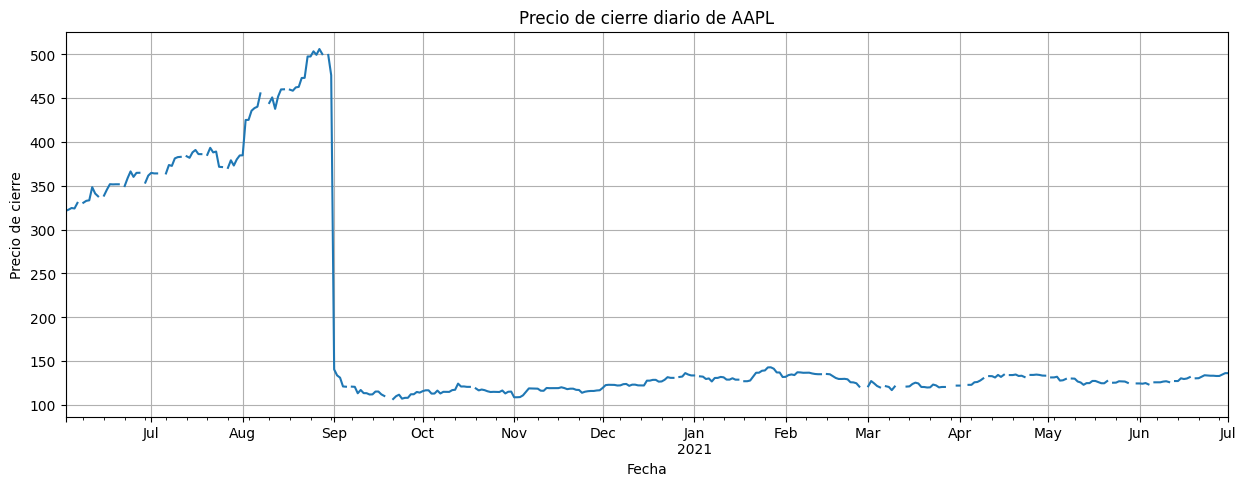

In [11]:
lista_dfs[0]['close'].plot(figsize=(15,5))
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True)
plt.title("Precio de cierre diario de AAPL")

In [12]:
# for df in lista_dfs:
#     df['close'].plot(figsize=(15,5))

Se ve que hay NAs, ya que al quitar los días que no están en NYSE (fin de semana y festiuvos) y al hacer frecuencia diaria, aparecen estos NAs sí o sí.
Los imputaremos con forward fill porque es lo que tiene más sentido, que estos días mantengan el precio de cierre del día anterior. Luego hacemos backward fill por si acaso al principio de la serie hay algún NA.

In [13]:
for i,df in enumerate(lista_dfs):
    df['close'] = df['close'].ffill().bfill()
    
    lista_dfs[i] = df

Text(0.5, 1.0, 'Precio de cierre diario de AAPL')

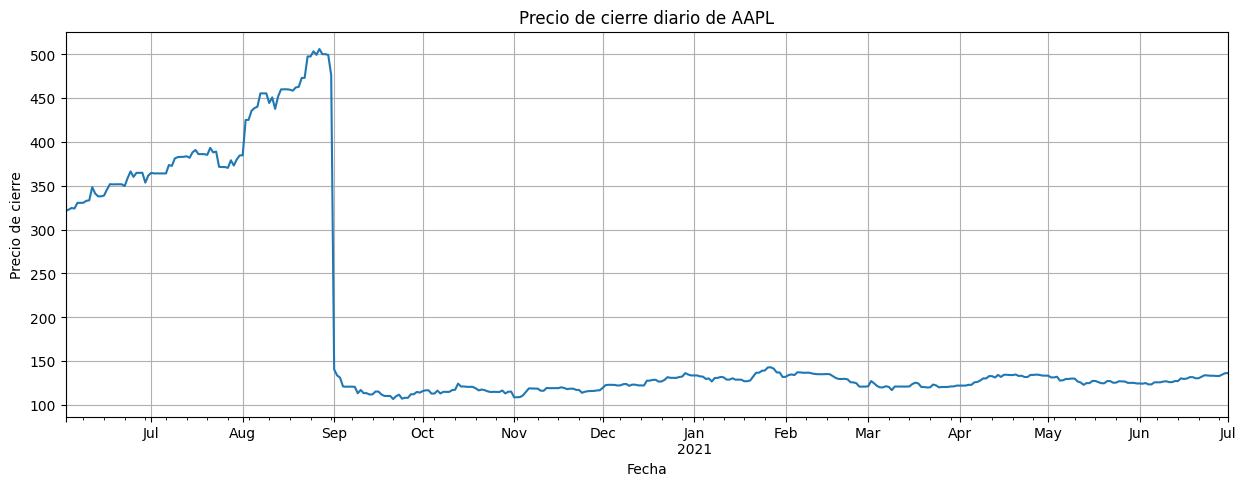

In [14]:
lista_dfs[0]['close'].plot(figsize=(15,5))
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True)
plt.title("Precio de cierre diario de AAPL")

In [15]:
# hola['LOCF'] = hola['close'].ffill().bfill()
# # plot our time series with imputed values
# plt.figure(figsize=(15,5))
# plt.plot(hola['LOCF'], color='blue')
# plt.plot(hola['close'],color='red' )

# SPLITS

Como ya se ve en el gráfico de AAPL, hay que tratar los posibles splits que tienen los índices. Para ello, nos descargamos los datos de cada índice (ticker) de YAHOO FINANCE y con el método .splits veremos los posibles splits que tenga cada serie. Si lo tiene, ajustaremos los datos anteriores al split dividiendolo por el factor correspondiente.

In [ ]:
import yfinance as yf
import pandas as pd

for i, df in enumerate(lista_dfs):
    # Descargamos splits reales
    symbol = df['symbol'].iloc[0]
    splits = yf.Ticker(symbol).splits

    if splits.empty:
        lista_dfs[i] = df
        continue

    # Normalizamos tz de splits para que coincida con df.index
    # Si splits.index viene sin tz, lo localizamos; si viene con UTC, lo convertimos
    if splits.index.tz is None:
        splits.index = splits.index.tz_localize("America/New_York")
    else:
        splits.index = splits.index.tz_convert("America/New_York")

    # Definimos el rango con tz NY
    fecha_min = pd.Timestamp("2020-06-02", tz="America/New_York")
    fecha_max = pd.Timestamp("2021-07-01", tz="America/New_York")

    # Filtramos splits dentro de la ventana
    splits = splits.loc[(splits.index >= fecha_min) & (splits.index <= fecha_max)]
    if splits.empty:
        lista_dfs[i] = df
        continue

    print(f"\n📅 Splits reales para {symbol} entre {fecha_min.date()} y {fecha_max.date()}:")
    print(splits)

    if df.index.tz is None:
        df.index = df.index.tz_localize("America/New_York")
    else:
        df.index = df.index.tz_convert("America/New_York")

    # Ajustamos precios retrospectivamente
    for split_date, factor in splits.items():
        mask = df.index <= split_date
        for col in ['open','high','low','close']:
            if col in df.columns:
                df.loc[mask, col] /= factor

    lista_dfs[i] = df



📅 Splits reales para AAPL entre 2020-06-02 y 2021-07-01:
Date
2020-08-31 00:00:00-04:00    4.0
Name: Stock Splits, dtype: float64

📅 Splits reales para MRK entre 2020-06-02 y 2021-07-01:
Date
2021-06-03 00:00:00-04:00    1.048
Name: Stock Splits, dtype: float64


Text(0.5, 1.0, 'Precio de cierre diario de AAPL (con split ajustado)')

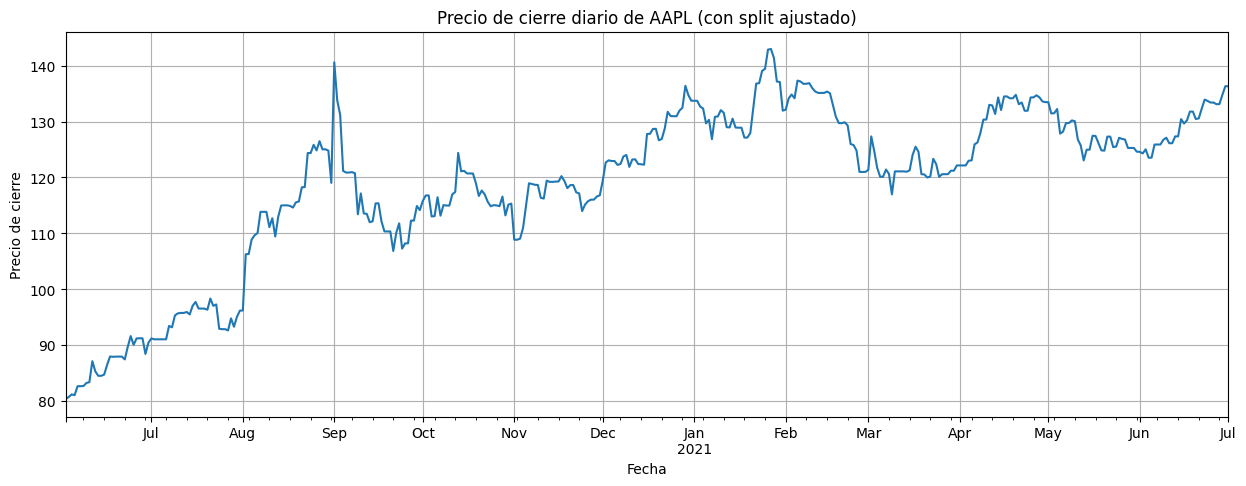

In [17]:
lista_dfs[0]['close'].plot(figsize=(15,5))
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True)
plt.title("Precio de cierre diario de AAPL (con split ajustado)")

[*********************100%***********************]  1 of 1 completed


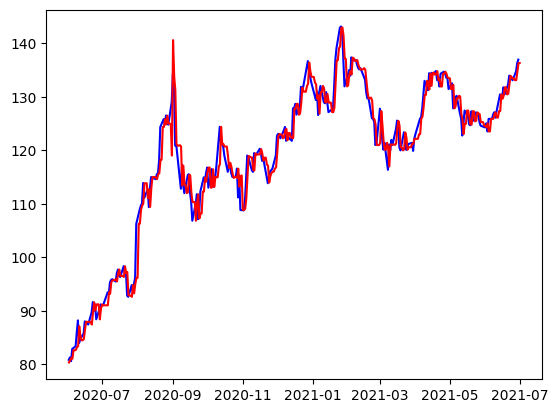

In [18]:
data = yf.download("AAPL", start="2020-06-02", end="2021-07-01", auto_adjust=False)
plt.plot(data['Close'], color='blue')
plt.plot(lista_dfs[0]['close'],color='red')

## SE VE QUE ESTÁ BIEN AJUSTADO COMPARANDO CON YAHOO FINANCE

# RENTABILIDADES

Calculamos rentabilidad diaria y juntamos todo en un mismo df.

In [19]:
dfs_pct = []

for i, df in enumerate(lista_dfs):
    # Quedarse solo con 'close' y 'symbol'
    df = df[["close", "symbol"]].copy()

    # Calcular variación porcentual diaria
    df["rent"] = df["close"].pct_change()

    # Eliminar la primera fila (NaN en pct_change)
    df = df.dropna(subset=["rent"])

    # Guardar en la lista
    dfs_pct.append(df)

# Unir todos los DataFrames en uno solo
df_final = pd.concat(dfs_pct)

# Hay problemas con fechas, lo arreglamos
df_final.index = df_final.index.astype(str)
df_final.index = df_final.index.map(lambda x: pd.to_datetime(x).replace(tzinfo=None))

df_final

,close,symbol,rent
trading_day,,,
2020-06-03,80.703070,AAPL,0.004507
2020-06-04,81.168741,AAPL,0.005770
2020-06-05,81.035490,AAPL,-0.001642
2020-06-06,82.633810,AAPL,0.019724
2020-06-07,82.633810,AAPL,0.000000
...,...,...,...
2021-06-27,395.570997,UNH,0.000000
2021-06-28,404.950000,UNH,0.023710
2021-06-29,401.460000,UNH,-0.008618


In [20]:
# Función para calcular rentabilidades anualizadas
def rtb_anualizada(tipo, n, p0, p1, dias_habiles):
    if tipo == 'd':
        r = (p1 - p0) / p0
        return ((1 + r) ** (dias_habiles / n)) - 1

    elif tipo == 'm':
        r = (p1 - p0) / p0
        return ((1 + r) ** (12 / n)) - 1

    elif tipo == 'y':
        r = (p1 - p0) / p0
        return ((1 + r) ** (1 / n)) - 1

    else:
        return("Por favor, introduzca 'd', 'm' o 'y' en el tipo")

Creamos dos df nuevos con los simbolos como columnas, el de precios_close tendrá los valores de close y el de rentabilidades los valores de rentabilidad diaria.

In [21]:
grouped = df_final.groupby([df_final.index, 'symbol']).agg({
        'close': 'first',
        'rent':  'first'
    })

precios_close = grouped['close'].unstack('symbol')
rentabilidades = grouped['rent'].unstack('symbol')

display(precios_close,rentabilidades)

symbol,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,JPM,KO,MCD,MMM,MRK,MSFT,NKE,PG,TRV,UNH
trading_day,,,,,,,,,,,,,,,,,,,,,
2020-06-03,80.703070,227.049500,96.670000,151.098421,124.717785,176.340617,46.317882,92.777176,118.749583,38.60,...,98.585172,46.986517,187.394648,155.595636,75.928901,182.834884,101.545703,117.231268,109.111930,305.910714
2020-06-04,81.168741,221.000000,105.400000,173.160000,126.596975,174.990000,46.940000,97.180000,122.180000,41.63,...,104.270000,47.900000,193.290000,161.210000,78.301527,185.360000,103.764024,118.530000,114.470000,305.350000
2020-06-05,81.035490,220.882264,106.521311,184.300000,130.070855,171.452326,46.860268,96.283237,123.684720,41.63,...,106.432543,47.919932,193.240179,162.544597,77.816668,182.928472,101.839924,116.059538,117.980919,298.108849
2020-06-06,82.633810,220.880000,106.540000,184.300000,134.747143,171.440000,46.860000,96.280000,123.690000,42.71,...,106.440000,47.920000,193.240000,162.550000,77.814885,182.920000,102.988333,116.050000,118.000000,298.080000
2020-06-07,82.633810,220.880000,106.540000,184.300000,134.747143,171.440000,46.860000,96.280000,123.690000,42.71,...,106.440000,47.920000,193.240000,162.550000,77.814885,182.920000,102.988333,116.050000,118.000000,298.080000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-27,133.110000,240.950000,168.202551,248.380000,216.310000,241.870000,53.060000,107.300000,178.350000,63.11,...,154.050000,54.320000,233.330000,193.260000,77.200000,265.020000,154.350000,133.020000,149.970000,398.870000
2021-06-28,133.135535,242.680508,169.450000,248.163408,216.309626,241.878682,53.059357,107.300000,178.290305,63.29,...,154.054502,54.320000,232.420000,194.750000,77.200000,265.124717,154.331048,134.920000,151.720000,404.950000
2021-06-29,134.783684,242.840000,164.780000,239.813797,216.270000,244.578052,52.959377,103.985831,176.536476,62.90,...,154.323762,54.258773,231.090000,196.500000,76.860000,268.712484,152.460969,135.320000,149.450000,401.460000


symbol,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,JPM,KO,MCD,MMM,MRK,MSFT,NKE,PG,TRV,UNH
trading_day,,,,,,,,,,,,,,,,,,,,,
2020-06-03,0.004507,0.000000,0.000000,0.000000,0.025683,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.019847,0.000000,0.000000,0.000000
2020-06-04,0.005770,-0.026644,0.090307,0.146008,0.015068,-0.007659,0.013431,0.047456,0.028888,0.078497,...,0.057664,0.019441,3.145955e-02,0.036083,0.031248,0.013811,0.021846,0.011078,0.049106,-0.001833
2020-06-05,-0.001642,-0.000533,0.010639,0.064334,0.027440,-0.020216,-0.001699,-0.009228,0.012316,0.000000,...,0.020740,0.000416,-2.577515e-04,0.008279,-0.006192,-0.013118,-0.018543,-0.020843,0.030671,-0.023714
2020-06-06,0.019724,-0.000010,0.000175,0.000000,0.035952,-0.000072,-0.000006,-0.000034,0.000043,0.025943,...,0.000070,0.000001,-9.274027e-07,0.000033,-0.000023,-0.000046,0.011277,-0.000082,0.000162,-0.000097
2020-06-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-27,-0.002249,0.000000,0.000000,-0.008740,-0.013814,-0.007794,0.005305,0.001493,0.002360,0.000000,...,0.010098,-0.001287,0.000000e+00,0.000000,0.011001,-0.006146,0.155586,0.000000,0.000000,0.000000
2021-06-28,0.000192,0.007182,0.007416,-0.000872,-0.000002,0.000036,-0.000012,0.000000,-0.000335,0.002852,...,0.000029,0.000000,-3.900056e-03,0.007710,0.000000,0.000395,-0.000123,0.014284,0.011669,0.015243
2021-06-29,0.012379,0.000657,-0.027560,-0.033646,-0.000183,0.011160,-0.001884,-0.030887,-0.009837,-0.006162,...,0.001748,-0.001127,-5.722399e-03,0.008986,-0.004404,0.013532,-0.012117,0.002965,-0.014962,-0.008618


### Hacemos una función que calcula las volatilidades diaria y anualizada, las rentabilidades media y anualizada. Devuelve un dataframe en el que salen esas variables por símbolo.

In [ ]:
def analisis_completo(precios, rentabilidades):

    # Cálculo de riesgo, rentabilidad media y Sharpe simulado
    volatilidad   = rentabilidades.std()
    volatilidad_anual = volatilidad * np.sqrt(252)
    rentabilidad  = rentabilidades.mean()
    df_riesgo_rent = pd.DataFrame({
        'Rentabilidad (media diaria)': rentabilidad,
        'Volatilidad (media diaria)': volatilidad,
        'Volatilidad_anual':  volatilidad_anual
    })
    df_riesgo_rent['Sharpe_sim'] = (
        df_riesgo_rent['Rentabilidad (media diaria)'] /
        df_riesgo_rent['Volatilidad (media diaria)']
    )

    # Rentabilidad anualizada (tipo 'd', 252 días hábiles)
    dias_habiles_anuales = 252
    n_periodo = len(precios.index)
    rent_anual = {
        sym: rtb_anualizada('d',
                            n_periodo,
                            precios[sym].iloc[0],
                            precios[sym].iloc[-1],
                            dias_habiles_anuales)
        for sym in precios.columns
    }
    df_riesgo_rent['Rent_anualizada'] = pd.Series(rent_anual)

    df_riesgo_rent = df_riesgo_rent.sort_values('Sharpe_sim', ascending=False)
    
    return df_riesgo_rent

In [23]:
df_riesgo_rent = analisis_completo(precios=precios_close, rentabilidades=rentabilidades)
df_riesgo_rent

,Rentabilidad (media diaria),Volatilidad (media diaria),Volatilidad_anual,Sharpe_sim,Rent_anualizada
symbol,,,,,
GS,0.001688,0.015685,0.248998,0.107613,0.459400
CAT,0.001567,0.015415,0.244707,0.101653,0.417097
MSFT,0.001090,0.013282,0.210853,0.082072,0.287087
NKE,0.001262,0.015848,0.251586,0.079612,0.315745
AAPL,0.001521,0.019147,0.303951,0.079444,0.398416
JPM,0.001266,0.016236,0.257733,0.077976,0.330907
AXP,0.001534,0.019735,0.313289,0.077747,0.403600
DOW,0.001435,0.019586,0.310915,0.073276,0.367689
DIS,0.001105,0.016737,0.265699,0.066045,0.276462


### CON ESOS CÁLCULOS: GRÁFICO DE RIESGO VS RENTABILIDAD (TODO ANUALIZADO), GRÁFICO DE CORRELACIONES (DE RENT DIARIA) Y LA EVOLUCIÓN TEMPORAL NORMALIZADA A BASE 100

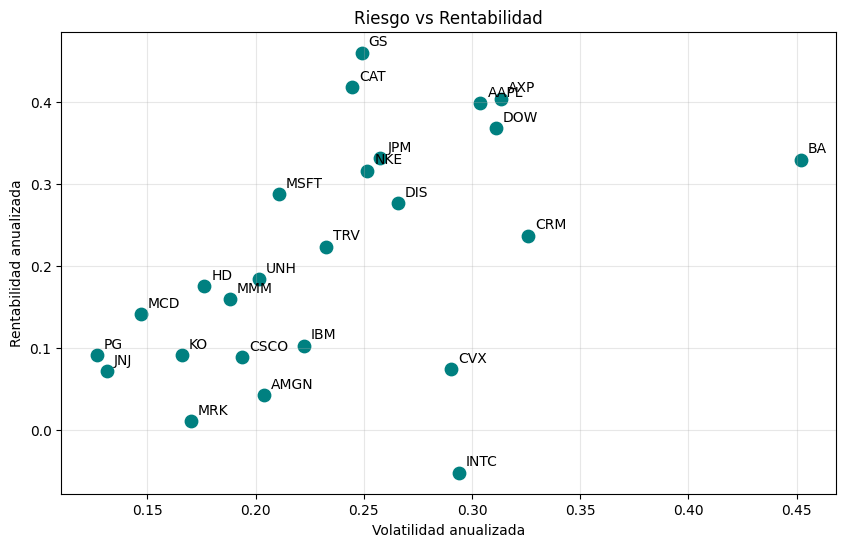

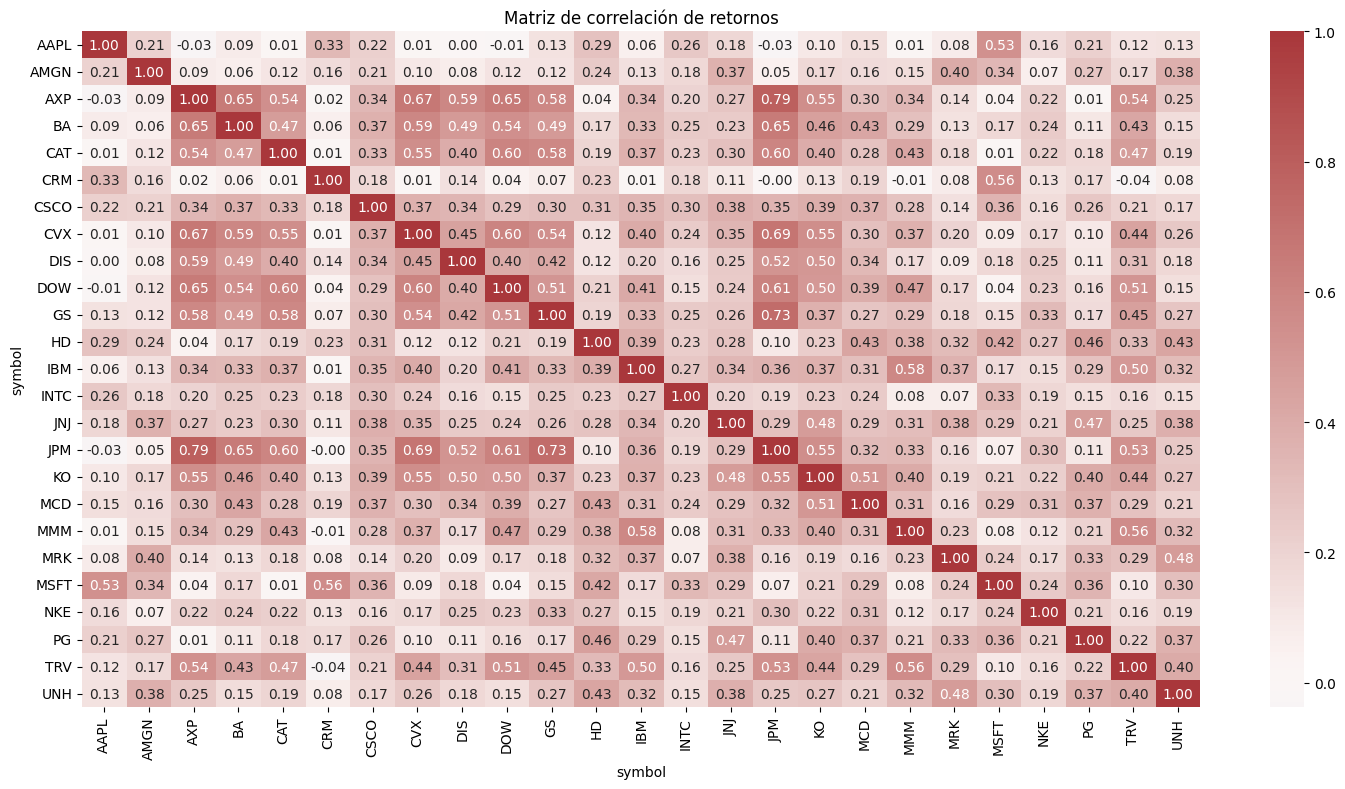

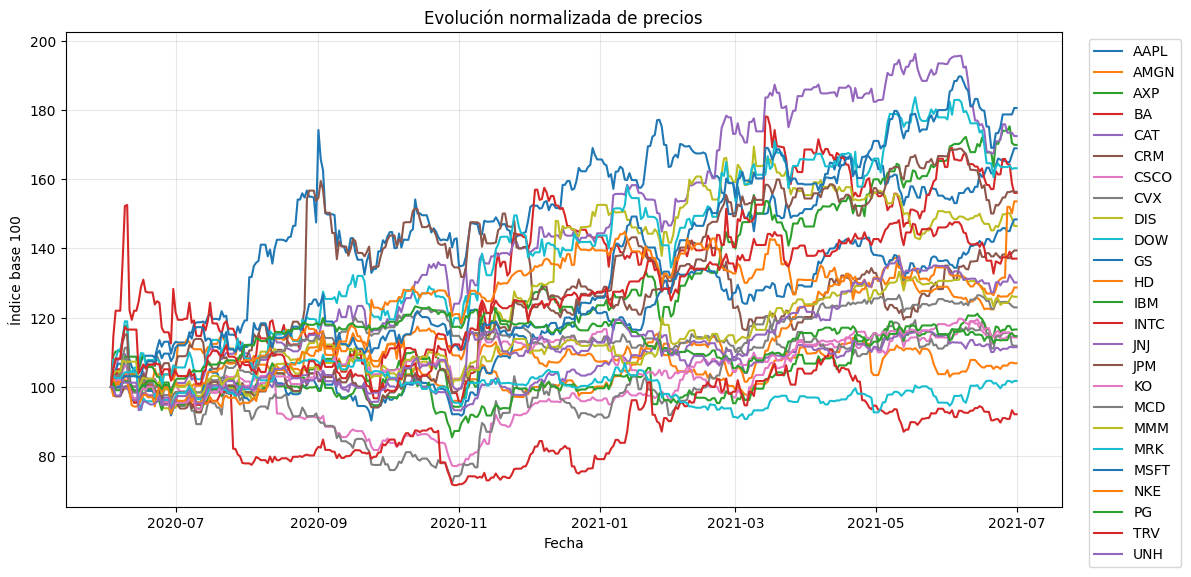

In [ ]:
import seaborn as sns

# Gráfico Riesgo vs Rentabilidad
plt.figure(figsize=(10, 6))
plt.scatter(df_riesgo_rent['Volatilidad_anual'],
            df_riesgo_rent['Rent_anualizada'],
            s=80, color='teal')
for sym in df_riesgo_rent.index:
    x = df_riesgo_rent.loc[sym, 'Volatilidad_anual']
    y = df_riesgo_rent.loc[sym, 'Rent_anualizada']
    plt.annotate(sym, (x, y), xytext=(5,5), textcoords="offset points")
plt.xlabel("Volatilidad anualizada")
plt.ylabel("Rentabilidad anualizada")
plt.title("Rentabilidad vs Riesgo")
plt.grid(alpha=0.3)
plt.show()

# Matriz de correlación de retornos
corr = rentabilidades.corr()
plt.figure(figsize=(15, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Matriz de correlación de retornos")
plt.tight_layout()
plt.show()

# Evolución temporal normalizada a base 100
precios_norm = precios_close.div(precios_close.iloc[0]).mul(100)
plt.figure(figsize=(12, 6))
for sym in precios_norm.columns:
    plt.plot(precios_norm.index, precios_norm[sym], label=sym)
plt.xlabel("Fecha")
plt.ylabel("Índice base 100")
plt.title("Evolución normalizada de precios")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## ELEGIMOS LOS ACTIVOS AAPL, MSFT Y CAT (estará explicado en el informe)
Guardamos datos limpios en csv

In [25]:
path_clean_data = os.path.join('Datos','Limpios')
if not os.path.exists(path_clean_data):
  os.makedirs(path_clean_data)

In [26]:
file_clean = os.path.join(path_clean_data,'Precios_Close.csv')
precios_close.to_csv(file_clean, index=True, encoding='UTF-8')

In [27]:
file_clean = os.path.join(path_clean_data,'Rentabilidades.csv')
rentabilidades.to_csv(file_clean, index=True, encoding='UTF-8')

In [28]:
file_clean = os.path.join(path_clean_data,'Analisis_activos.csv')
df_riesgo_rent.to_csv(file_clean, index=True, encoding='UTF-8')

In [29]:
cartera_p = precios_close[['AAPL','MSFT','CAT']]
file_clean = os.path.join(path_clean_data,'Cartera_Close.csv')
cartera_p.to_csv(file_clean, index=True, encoding='UTF-8')

In [30]:
cartera_r = rentabilidades[['AAPL','MSFT','CAT']]
file_clean = os.path.join(path_clean_data,'Cartera_Rent.csv')
cartera_r.to_csv(file_clean, index=True, encoding='UTF-8')

## FUNCIÓN DE MONTECARLO CON RESULTADOS

In [31]:
def montecarlo_asian_basket(
    csv_path,
    symbols,
    K,
    T,
    trading_days_per_year,
    num_steps,
    num_sims,
    mu,
    E,
    S0,
    seed,
    plot,
    n_plot_sims,
    return_paths
):
    """
    Simula por Montecarlo una opción asiática tipo cesta con media geométrica,
    forzando que los primeros K pasos (t = 0..K) sean idénticos para todas las simulaciones.
    devuelve un dict con resultados.

    Parámetros:
    - csv_path: ruta al CSV con columnas 'trading_day', 'symbol', 'close'.
    - symbols: lista de símbolos a usar (ej: ["AAPL","MSFT","CAT"]). Si None, se usa
               el contenido del CSV (ordenado alfabéticamente).
   
    - K: número de primeros pasos donde la cesta y los activos serán idénticos.
    - T: horizonte total en años.
    - trading_days_per_year: días de trading por año (para anualizar vol).
    - num_steps: número de pasos discretos en [0, T].
    - num_sims: número de simulaciones Monte Carlo.
    - mu: drift anual (usado solo para descuento/drift en geom. browniano).
    - E: strike (en el script original se divide entre num_assets).
    - S0: array o lista con precios iniciales por activo. Si None, se usa 1.0 por activo.
    - seed: semilla para reproducibilidad.
    - plot: si True, genera los plots (trayectorias por activo y media geométrica).
    - n_plot_sims: número de simulaciones a dibujar por activo (máx 100 por default).
    - return_paths: si True, devuelve las matrices de caminos simulados (S, S_base), sino no para ahorrar memoria.

    Devuelve:
    dict con claves:
      - 'Y' : prima estimada (float)
      - 'V' : array de payoffs (por simulación, antes del descuento)
      - 'geom_mean_basket' : array (por simulación) de medias geométricas usadas en payoff
      - 'sigma_annual' : volatilidades anualizadas por activo
      - 'corr_matrix' : matriz de correlación entre activos (por rendimientos históricos)
      - 'prices_df' : DataFrame de precios leídos (pivot)
      - 'S' : (opcional) array de caminos simulados shape (num_sims, num_steps+1, n_assets)
      - 'S_base' : (opcional) array (K+1, n_assets) del camino base para 0..K
    """
    np.random.seed(seed)

    if symbols is None:
        # leer csv para obtener símbolos si no se dieron
        tmp_df = pd.read_csv(csv_path)
        symbols = sorted(tmp_df['symbol'].unique().tolist())

    # Leer CSV y preparar series
    df = pd.read_csv(csv_path, index_col='trading_day')
    prices_df = df.dropna()[symbols]
    prices_norm = prices_df / prices_df.iloc[0]

    # Correlación y volatilidades basadas en rendimientos log
    log_ret = np.diff(np.log(prices_norm.values), axis=0)
    corr_matrix = np.corrcoef(log_ret.T)
    # cholesky de la matriz de correlación (A) para generar increments correlacionados
    A = np.linalg.cholesky(corr_matrix)
    sigma_daily = np.std(log_ret, axis=0, ddof=1)
    sigma_annual = sigma_daily * np.sqrt(trading_days_per_year)

    # parámetros iniciales
    n_assets = len(symbols)
    if S0 is None:
        S0 = np.ones(n_assets)
    else:
        S0 = np.array(S0, dtype=float)
        if S0.shape[0] != n_assets:
            raise ValueError("S0 debe tener la misma longitud que symbols")

    # imprimir info rápida (como en el script original)
    print("Volatilidades anualizadas:", np.round(sigma_annual, 6))
    print("Matriz de correlación (basada en rendimientos):\n", np.round(corr_matrix, 6))

    # generar incrementos brownianos correlacionados para todas las simulaciones
    dt = T / num_steps
    dW_uncorr = np.random.normal(size=(num_sims, num_steps, n_assets), scale=np.sqrt(dt))
    dW = dW_uncorr.dot(A.T)  # ahora correlated

    # construir camino base único para primeros K pasos (t = 0..K)
    base_uncorr = np.random.normal(size=(K, n_assets), scale=np.sqrt(dt))
    base_dW = base_uncorr.dot(A.T)
    S_base = np.zeros((K + 1, n_assets))
    S_base[0, :] = S0
    # drift por paso (vector)
    drift_vec = (mu - 0.5 * sigma_annual**2) * dt
    for t in range(1, K + 1):
        diffusion = sigma_annual * base_dW[t - 1, :]  # (n_assets,)
        S_base[t, :] = S_base[t - 1, :] * np.exp(drift_vec + diffusion)

    # Simulación completa forzando activos idénticos en t<=K y continuidad desde K
    S = np.zeros((num_sims, num_steps + 1, n_assets))
    S[:, 0, :] = S0
    for t in range(1, num_steps + 1):
        if t <= K:
            # forzamos que TODAS las simulaciones tengan exactamente los mismos valores por activo en t
            S[:, t, :] = S_base[t][np.newaxis, :].repeat(num_sims, axis=0)
        else:
            # a partir de t = K+1, cada simulación sigue su propio camino partiendo de S[:, t-1, :]
            diffusion = sigma_annual * dW[:, t - 1, :]  # shape (num_sims, n_assets)
            S[:, t, :] = S[:, t - 1, :] * np.exp(drift_vec + diffusion)

    # Cálculo del payoff: opción asiática 'cesta' con media geométrica
    # basket_values por paso (media aritmética entre activos)
    basket_values = S.mean(axis=2)  # shape (num_sims, num_steps+1)
    # según tu script original: gmean de ratios respecto al paso 0 (parece intención de promediar incrementos)
    # recreamos el cálculo original:
    # evitamos dividir por 0 si basket_values[:,0] es 0 (muy improbable si S0>0)
    denom = basket_values[:, 0].copy()
    denom[denom == 0] = 1e-12
    geom_mean_basket = gmean(basket_values[:, 1:] / denom[:, None], axis=1)
    V = np.maximum(geom_mean_basket - E / n_assets, 0)
    Y = np.exp(-mu * T) * np.mean(V)

    print(f"Prima estimada (Montecarlo, call asiática cesta geométrica) con activos idénticos en t<= {K}: {Y:.6f}")

    results = {
        "Y": Y,
        "V": V,
        "geom_mean_basket": geom_mean_basket,
        "sigma_annual": sigma_annual,
        "corr_matrix": corr_matrix,
        "prices_df": prices_df,
        "symbols": symbols
    }

    if return_paths:
        results["S"] = S
        results["S_base"] = S_base

    # Plots (opcional)
    if plot:
        n_pasos = num_steps + 1
        n_plot_sims = min(n_plot_sims, num_sims)
        plt.figure(figsize=(15, 5))
        activos = [f'Activo {i+1}, {symbols[i]} (σ={sigma_annual[i]:.4f})' for i in range(n_assets)]

        # xticks razonables
        if n_pasos <= 20:
            xtick_step = 1
        else:
            xtick_step = max(1, n_pasos // 10)

        for i in range(n_assets):
            plt.subplot(1, n_assets, i + 1)
            # 1 línea única para t=0..K: la trayectoria base S_base
            plt.plot(np.arange(0, K + 1), S_base[:, i], color='black', linewidth=2.0, label='Camino único (0..K)')
            # líneas individuales que comienzan exactamente en el punto en t=K (igual para todos) y siguen hasta el final
            x_range = np.arange(K, n_pasos)
            for j in range(n_plot_sims):
                plt.plot(x_range, S[j, K:, i], alpha=0.5, linewidth=0.8)
            plt.title(f"Trayectorias simuladas - {activos[i]}")
            plt.xlabel("Tiempo (pasos)")
            plt.xlim(0, n_pasos - 1)
            plt.xticks(np.arange(0, n_pasos, xtick_step))
            plt.ylabel("Precio simulado")
            plt.grid(True, alpha=0.3)
            plt.axvline(x=K, color='red', linestyle='--', alpha=0.7, label='Fin pasos iguales' if i == 0 else "")
            if i == 0:
                plt.legend()
        plt.tight_layout()
        plt.show()

        # Media geométrica de la cartera: 1 línea base en 0..K y varias trayectorias desde K..end
        S_geom = gmean(S, axis=2)
        plt.figure(figsize=(10, 6))
        plt.plot(np.arange(0, K + 1), gmean(S_base, axis=1), color='black', linewidth=2.0, label='Camino único geom (0..K)')
        x_range = np.arange(K, n_pasos)
        for j in range(min(30, num_sims)):
            plt.plot(x_range, S_geom[j, K:], alpha=0.5, linewidth=0.8)
        plt.title("Trayectorias - Media geométrica de la cartera")
        plt.xlabel("Tiempo (pasos)")
        plt.ylabel("Precio medio geométrico")
        plt.xlim(0, n_pasos - 1)
        plt.xticks(np.arange(0, n_pasos, xtick_step))
        plt.axvline(x=K, color='red', linestyle='--', alpha=0.7, label='Fin pasos iguales')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return results

Volatilidades anualizadas: [0.298436 0.211289 0.243742]
Matriz de correlación (basada en rendimientos):
 [[1.       0.54924  0.009005]
 [0.54924  1.       0.005686]
 [0.009005 0.005686 1.      ]]
Prima estimada (Montecarlo, call asiática cesta geométrica) con activos idénticos en t<= 5: 0.050604


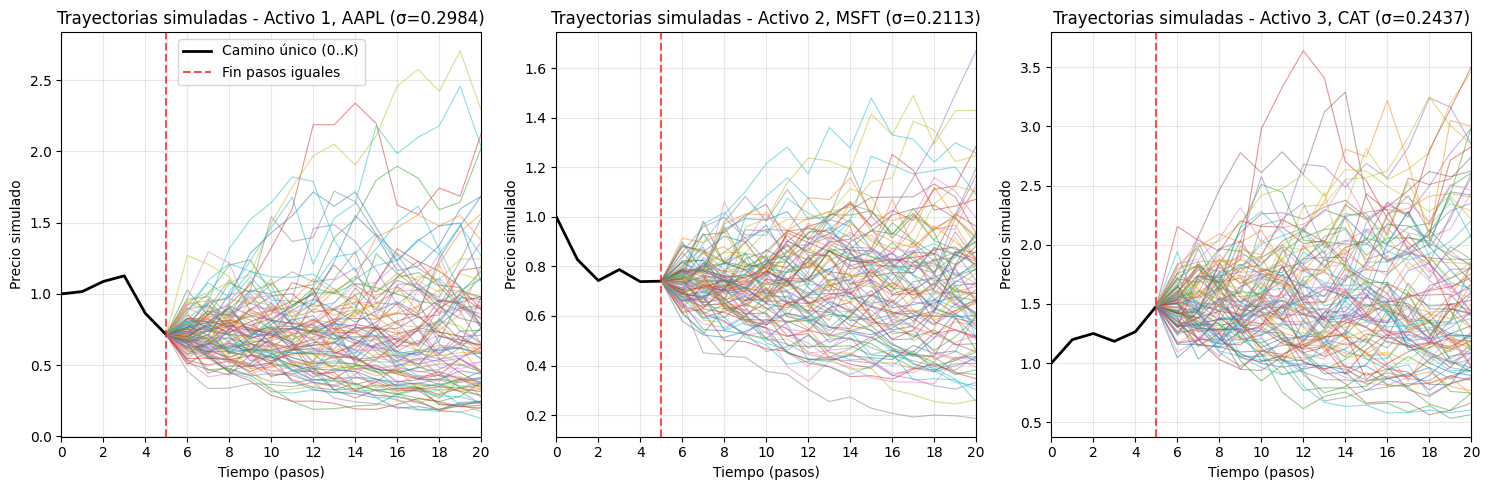

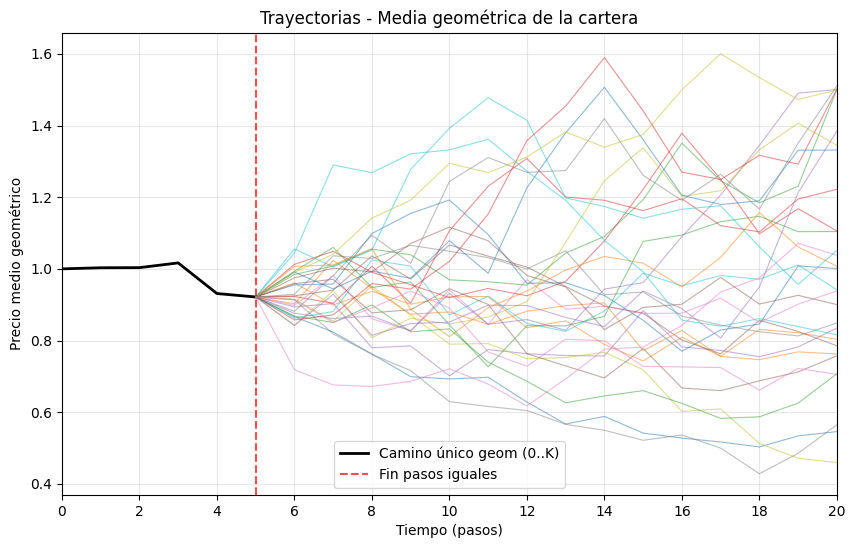

0.05060441760968008


In [32]:
res = montecarlo_asian_basket(
    csv_path="Datos/Limpios/Precios_Close.csv",
    symbols=["AAPL", "MSFT", "CAT"],
    K=5,
    T=5.0,
    trading_days_per_year=252,
    num_steps=20,
    num_sims=100_000,
    mu=0.01,
    E=3.0,
    S0=[1.0, 1.0, 1.0],
    seed=42,
    plot=True,
    n_plot_sims=100,
    return_paths=True
)

print(res["Y"])